# 06 — Intent-tree architecture: real vs. extracted, before & after regrouping

Complements NB5 (semantic *recovery*) with a **structural / architecture** view: how does the *shape*
of the extracted tree compare to the **real** DiscoverLLM tree, and **does the regrouping step move it
closer**?

For each artifact we compare three trees:
- **real** — the ground-truth DiscoverLLM tree, scoped to **green + yellow (surfaced)** nodes
  (consistent with NB5; the conversation can't surface red nodes). Kept nodes are re-parented to their
  nearest surfaced ancestor so the subtree shape is correct.
- **before** — the raw extraction (`_raw_extraction` inside each `data/extractions_discoverllm/` file).
- **after** — the same extraction after the regrouping pass (top-level `trees`).

**Architecture descriptors** (label-free shape): `n_nodes` (size), `depth`, `branching` (mean children
of internal nodes), `leaf_ratio`. Headline metric: **shape-distance to the real tree** (Euclidean on
z-scored depth/branching/leaf_ratio) for *before* and *after* — if `after < before`, regrouping makes the
architecture more real-tree-like. The last cell repeats it against a **pure-green** real tree.

## Notes

- Default real-tree scope is **green + yellow (surfaced)** — same as NB5, so the two notebooks line up.
- Shape descriptors are size-normalized (`depth`/`branching`/`leaf_ratio` don't scale with node count).
- Same 15 `gpt-5.4-mini` artifacts; small N — directional. A label-aware tree-edit distance (`zss`) is a
  drop-in upgrade.

In [1]:
import os
import json
import ast
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _repo_root():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "requirements.txt").exists() and (cand / "notebooks").is_dir():
            return cand
    return Path.cwd()

ROOT = _repo_root()

def _loads(s):
    try:
        return json.loads(s)
    except Exception:
        return ast.literal_eval(s)

def descriptors(trees_nodes):
    """trees_nodes: list of per-tree node lists; each node has id + parent_id (None for a root)."""
    n_nodes, depths, branch, leaves = 0, [], [], 0
    for nodes in trees_nodes:
        by = {x["id"]: x for x in nodes}
        kids = Counter(x.get("parent_id") for x in nodes if x.get("parent_id") in by)
        for x in nodes:
            n_nodes += 1
            d, cur = 1, x
            while cur.get("parent_id") in by:
                cur = by[cur["parent_id"]]; d += 1
            depths.append(d)
            k = kids.get(x["id"], 0)
            if k == 0:
                leaves += 1
            else:
                branch.append(k)
    if n_nodes == 0:
        return {"n_nodes": 0, "depth": 0, "branching": 0.0, "leaf_ratio": 0.0}
    return {"n_nodes": n_nodes, "depth": max(depths),
            "branching": round(sum(branch) / len(branch), 2) if branch else 0.0,
            "leaf_ratio": round(leaves / n_nodes, 3)}

def _keep(n, scope):
    if scope == "green":
        return n.get("satisfied", 0) > 0
    if scope == "surfaced":                       # green + yellow
        return n.get("aware", 0) > 0 or n.get("satisfied", 0) > 0
    return True                                   # "full"

def gt_flatten(nested_trees, scope="surfaced"):
    """Nested GT -> per-tree flat node lists (id + parent_id), keeping only nodes passing `scope` and
    re-parenting each kept node to its nearest kept ancestor (correct subtree shape)."""
    out = []
    def walk(n, kept_parent, acc):
        nid = str(n["id"])
        if _keep(n, scope):
            acc.append({"id": nid, "parent_id": kept_parent}); nxt = nid
        else:
            nxt = kept_parent
        for c in n.get("children", []):
            walk(c, nxt, acc)
    for t in nested_trees:
        acc = []; walk(t, None, acc)
        if acc:
            out.append(acc)
    return out

def ext_trees_nodes(doc):
    return [t.get("nodes", []) for t in doc.get("trees", [])]

In [2]:
# --- Load: regrouped DiscoverLLM extractions (carry before=_raw_extraction + after) and GT ---
EXT_DIR = ROOT / "data" / "extractions_discoverllm"
docs = {}
for f in sorted(EXT_DIR.glob("*.json")):
    d = json.loads(f.read_text())
    if not d.get("error") and d.get("regrouped") and "_raw_extraction" in d:
        docs[f.stem] = d

gt_df = pd.read_csv(ROOT / "data" / "discoverllm_creative_writing_conversations.csv")
gt = {r["artifact_id"]: _loads(r["trees"]) for _, r in gt_df.iterrows()}
ids = sorted(set(docs) & set(gt))
print(f"artifacts with before+after extraction and GT: {len(ids)}")

def build_profile(real_scope):
    rows = []
    for aid in ids:
        d = docs[aid]
        rows.append({"artifact": aid, "tree": "real",   **descriptors(gt_flatten(gt[aid], real_scope))})
        rows.append({"artifact": aid, "tree": "before", **descriptors(ext_trees_nodes(d["_raw_extraction"]))})
        rows.append({"artifact": aid, "tree": "after",  **descriptors(ext_trees_nodes(d))})
    return pd.DataFrame(rows)

# DEFAULT: real tree = green + yellow (surfaced)
prof = build_profile("surfaced")
means = prof.groupby("tree")[["n_nodes", "depth", "branching", "leaf_ratio"]].mean().round(2).reindex(["real", "before", "after"])
print("\nmean architecture descriptors (real = green+yellow / surfaced):")
print(means)

artifacts with before+after extraction and GT: 15

mean architecture descriptors (real = green+yellow / surfaced):
        n_nodes  depth  branching  leaf_ratio
tree                                         
real      10.80   4.40       1.30        0.50
before     9.93   4.40       2.35        0.59
after      9.20   4.33       2.42        0.58


[green+yellow] mean shape-distance to real:  before=2.10  after=2.27  (lower = more real-tree-like)
[green+yellow] regrouping moved closer to real in 3/15 artifacts
size (n_nodes): real=10.8  before=9.9  after=9.2


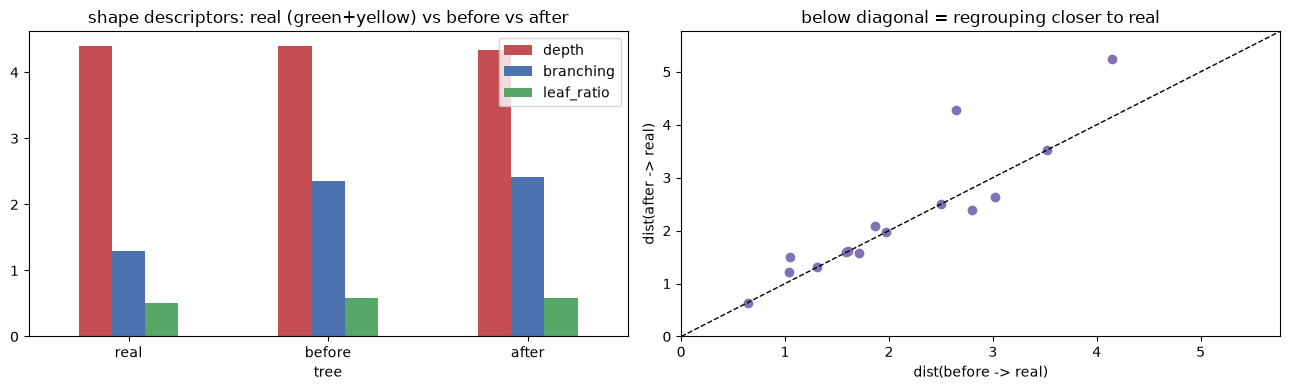

In [3]:
# --- Shape-distance to the real tree (z-scored depth/branching/leaf_ratio) ---
feat = ["depth", "branching", "leaf_ratio"]

def shape_distance(profile):
    Z = profile.copy()
    for c in feat:
        sd = profile[c].std() or 1.0
        Z[c] = (profile[c] - profile[c].mean()) / sd
    zv = {(r.artifact, r.tree): np.array([getattr(r, c) for c in feat]) for r in Z.itertuples()}
    rows = []
    for aid in ids:
        db = float(np.linalg.norm(zv[(aid, "before")] - zv[(aid, "real")]))
        da = float(np.linalg.norm(zv[(aid, "after")] - zv[(aid, "real")]))
        rows.append({"artifact": aid, "dist_before": round(db, 2), "dist_after": round(da, 2), "improved": da < db})
    return pd.DataFrame(rows)

dd = shape_distance(prof)
print(f"[green+yellow] mean shape-distance to real:  before={dd.dist_before.mean():.2f}  after={dd.dist_after.mean():.2f}  "
      f"(lower = more real-tree-like)")
print(f"[green+yellow] regrouping moved closer to real in {int(dd.improved.sum())}/{len(dd)} artifacts")
print(f"size (n_nodes): real={means.loc['real','n_nodes']:.1f}  before={means.loc['before','n_nodes']:.1f}  after={means.loc['after','n_nodes']:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
means[["depth", "branching", "leaf_ratio"]].plot.bar(ax=axes[0], color=["#C44E52", "#4C72B0", "#55A868"])
axes[0].set_title("shape descriptors: real (green+yellow) vs before vs after"); axes[0].tick_params(axis="x", rotation=0)
axes[1].scatter(dd.dist_before, dd.dist_after, c="#8172B3")
lim = max(dd.dist_before.max(), dd.dist_after.max(), 0.1) * 1.1
axes[1].plot([0, lim], [0, lim], "k--", lw=1)
axes[1].set_xlim(0, lim); axes[1].set_ylim(0, lim)
axes[1].set_xlabel("dist(before -> real)"); axes[1].set_ylabel("dist(after -> real)")
axes[1].set_title("below diagonal = regrouping closer to real")
plt.tight_layout(); plt.show()

In [4]:
# --- Non-default readout: PURE GREEN (satisfied-only) real tree, for comparison ---
prof_g = build_profile("green")
means_g = prof_g.groupby("tree")[["n_nodes", "depth", "branching", "leaf_ratio"]].mean().round(2).reindex(["real", "before", "after"])
dg = shape_distance(prof_g)
print("mean architecture descriptors (real = GREEN ONLY):")
print(means_g)
print(f"\n[green-only] mean shape-distance to real:  before={dg.dist_before.mean():.2f}  after={dg.dist_after.mean():.2f}")
print(f"[green-only] regrouping moved closer to real in {int(dg.improved.sum())}/{len(dg)} artifacts")
print(f"\nreal-tree size: green+yellow={means.loc['real','n_nodes']:.1f} nodes   green-only={means_g.loc['real','n_nodes']:.1f} nodes")

mean architecture descriptors (real = GREEN ONLY):
        n_nodes  depth  branching  leaf_ratio
tree                                         
real       7.93   3.67       1.30        0.43
before     9.93   4.40       2.35        0.59
after      9.20   4.33       2.42        0.58

[green-only] mean shape-distance to real:  before=2.31  after=2.45
[green-only] regrouping moved closer to real in 3/15 artifacts

real-tree size: green+yellow=10.8 nodes   green-only=7.9 nodes


## Takeaways

- **Default real tree = green + yellow (surfaced)**, re-parented — consistent with NB5, so size is now
  comparable (no longer dominated by the red nodes).
- The descriptor table + scatter show whether the regrouping step moves the extracted architecture toward
  the real (surfaced) tree's shape (`after < before`).
- The final cell repeats the comparison against a **pure-green** (satisfied-only) real tree — an even
  smaller, stricter target.
- Caveats: shape-only (labels ignored), N=15. **Upgrade:** label-aware tree-edit distance (`zss`).